# Clase Teórica: SVM, SVR y SVD — Enfoque Conceptual

**Machine Learning 1 — FIUNA**

**Docente:** Diego Stalder | **Práctica:** Carlos Benítez

---

## Descripción

Esta clase presenta los **fundamentos conceptuales** de SVM, SVR y SVD con énfasis en:

1. **Intuición geométrica** antes que fórmulas
2. **Pocas ecuaciones fundamentales** (solo las esenciales)
3. **Ejemplos numéricos originales** (escenarios diferentes a la práctica C7)
4. **Derivaciones simbólicas con SymPy** para verificar cada paso

## Estructura

| Sección | Tema | Ejemplo Original |
|---------|------|------------------|
| 1 | SVM: La frontera más segura | Detección de spam (enlaces vs palabras) |
| 2 | El truco del kernel | Predicción de aprobación con parciales |
| 3 | SVR: Regresión robusta | Nota final vs horas de trabajo |
| 4 | Hiperparámetros $C$ y $\gamma$ | Tres configuraciones comparadas |
| 5 | SVD: La navaja suiza | 5 variables académicas → 2 componentes |
| 6 | Síntesis integradora | Pipeline completo con datos sintéticos |

## 0. Importaciones y Configuración

In [1]:
# Librerías numéricas y de visualización
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías simbólicas
import sympy as sp
from sympy import symbols, Matrix, simplify, diff, solve, Rational, sqrt, exp, Eq, latex, init_printing

# Librerías de Machine Learning
from sklearn.svm import SVC, SVR
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from sklearn.datasets import make_classification, make_moons

# Configuración de SymPy para renderizado LaTeX
init_printing(use_latex='mathjax')

# Configuración de gráficos
plt.rcParams.update({
    'figure.figsize': (9, 5),
    'font.size': 11,
    'axes.grid': True,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 100
})
sns.set_palette('husl')
np.random.seed(2026)

print("Configuración completa. SymPy versión:", sp.__version__)
print("Las expresiones simbólicas se renderizarán como LaTeX con MathJax.")

Configuración completa. SymPy versión: 1.13.1
Las expresiones simbólicas se renderizarán como LaTeX con MathJax.


---
# Parte 1: SVM como Clasificador — La Frontera Más Segura

## 1.1 La intuición geométrica

Imagina que debes separar dos grupos de puntos con una línea recta. Existen **infinitas líneas** que logran la separación, pero SVM elige la que está **más lejos** de ambos grupos. Esta línea tiene el **margen máximo**.

**Analogía:** Es como trazar una carretera entre dos ciudades. No queremos que pase pegada a las casas; queremos la ruta más centrada y ancha.

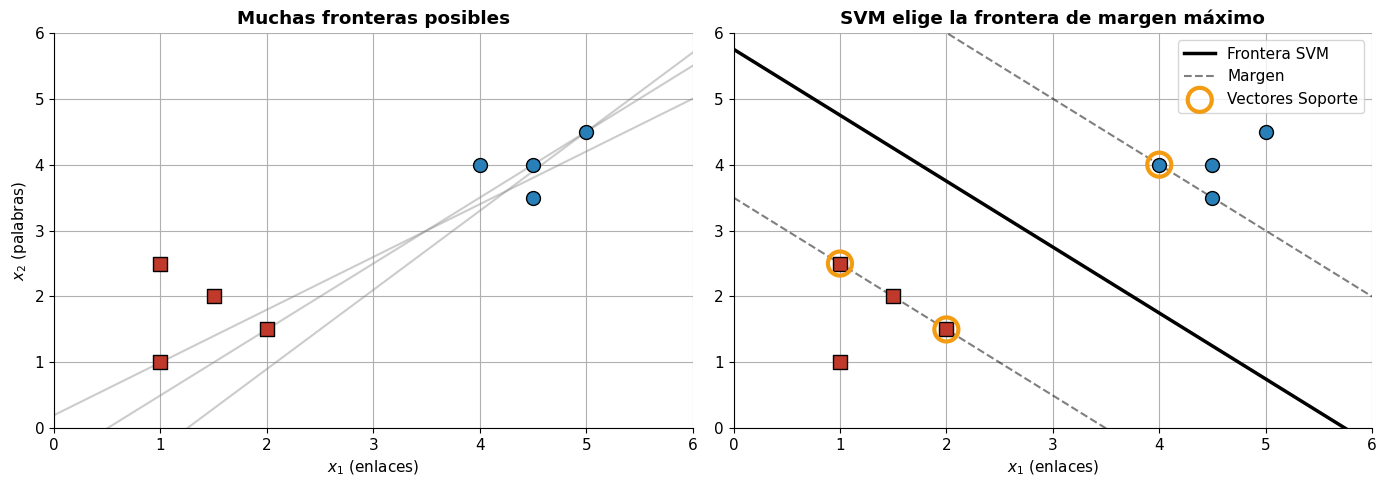

In [2]:
# Visualización de la intuición: múltiples fronteras posibles vs la frontera de margen máximo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Generamos datos de ejemplo
np.random.seed(2026)
X_demo = np.array([[1, 1], [2, 1.5], [1.5, 2], [1, 2.5],
                    [4, 4], [4.5, 3.5], [5, 4.5], [4.5, 4]])
y_demo = np.array([-1, -1, -1, -1, 1, 1, 1, 1])

# Panel izquierdo: múltiples fronteras
ax = axes[0]
ax.scatter(X_demo[y_demo==-1, 0], X_demo[y_demo==-1, 1], c='#C0392B', s=100, marker='s', edgecolor='k', zorder=3)
ax.scatter(X_demo[y_demo==1, 0], X_demo[y_demo==1, 1], c='#2980B9', s=100, marker='o', edgecolor='k', zorder=3)
x_line = np.linspace(0, 6, 100)
for slope, intercept, color, alpha in [(1, -0.5, 'gray', 0.4), (0.8, 0.2, 'gray', 0.4), (1.2, -1.5, 'gray', 0.4)]:
    ax.plot(x_line, slope*x_line + intercept, color=color, alpha=alpha, linewidth=1.5)
ax.set_xlim(0, 6); ax.set_ylim(0, 6)
ax.set_title('Muchas fronteras posibles', fontweight='bold')
ax.set_xlabel('$x_1$ (enlaces)'); ax.set_ylabel('$x_2$ (palabras)')

# Panel derecho: frontera SVM óptima
ax = axes[1]
clf_demo = SVC(kernel='linear', C=1000)
clf_demo.fit(X_demo, y_demo)
ax.scatter(X_demo[y_demo==-1, 0], X_demo[y_demo==-1, 1], c='#C0392B', s=100, marker='s', edgecolor='k', zorder=3)
ax.scatter(X_demo[y_demo==1, 0], X_demo[y_demo==1, 1], c='#2980B9', s=100, marker='o', edgecolor='k', zorder=3)

# Frontera y márgenes
w = clf_demo.coef_[0]
b = clf_demo.intercept_[0]
xx = np.linspace(0, 6, 100)
yy_decision = -(w[0]*xx + b)/w[1]
ax.plot(xx, yy_decision, 'k-', linewidth=2.5, label='Frontera SVM')

# Márgenes
margin = 1/np.linalg.norm(w)
yy_up = yy_decision + margin*np.sqrt(1 + (w[0]/w[1])**2)
yy_down = yy_decision - margin*np.sqrt(1 + (w[0]/w[1])**2)
ax.plot(xx, yy_up, 'k--', alpha=0.5, label='Margen')
ax.plot(xx, yy_down, 'k--', alpha=0.5)

# Vectores de soporte
ax.scatter(clf_demo.support_vectors_[:, 0], clf_demo.support_vectors_[:, 1],
           s=300, facecolors='none', edgecolors='#F39C12', linewidths=3, label='Vectores Soporte', zorder=4)
ax.set_xlim(0, 6); ax.set_ylim(0, 6)
ax.set_title('SVM elige la frontera de margen máximo', fontweight='bold')
ax.set_xlabel('$x_1$ (enlaces)'); ax.legend()

plt.tight_layout()
plt.show()

## 1.2 La ecuación fundamental

Todo el poder de SVM se condensa en un **único problema de optimización**:

$$\min_{\mathbf{w}, b} \frac{1}{2}\|\mathbf{w}\|^2 \quad \text{sujeto a} \quad y_i(\mathbf{w}^\top \mathbf{x}_i + b) \ge 1$$

**Interpretación de cada elemento:**
- $\mathbf{w}$: dirección del hiperplano (vector normal)
- $b$: posición del hiperplano (sesgo)
- $y_i \in \{-1, +1\}$: etiquetas
- $\frac{1}{2}\|\mathbf{w}\|^2$: minimizar esto equivale a **maximizar el margen** $\frac{2}{\|\mathbf{w}\|}$
- $y_i(\mathbf{w}^\top \mathbf{x}_i + b) \ge 1$: cada punto debe estar al menos a distancia 1 del hiperplano

In [3]:
# Verificación simbólica: ¿Por qué minimizar ||w||^2 maximiza el margen?
print("=== Relación entre ||w|| y el margen ===\n")

# El margen geometrico vale 2/||w||
w1, w2 = sp.symbols('w_1 w_2', real=True)
norma_w = sp.sqrt(w1**2 + w2**2)
margen = 2 / norma_w

print("Margen geométrico:")
display(margen)

# Si ||w||=1, margen=2. Si ||w||=2, margen=1. Si ||w||=0.5, margen=4.
print("\nEjemplos numéricos:")
for nw in [0.5, 1.0, 2.0, 4.0]:
    print(f"  ||w|| = {nw:.1f}  ->  Margen = 2/{nw} = {2/nw:.2f}")

print("\n\\textbf{Conclusión:} Para maximizar el margen, debemos minimizar ||w||.")
print("Por conveniencia matemática, minimizamos (1/2)||w||^2 (misma solución, derivada más simple).")

=== Relación entre ||w|| y el margen ===

Margen geométrico:


      2       
──────────────
   ___________
  ╱   2     2 
╲╱  w₁  + w₂  


Ejemplos numéricos:
  ||w|| = 0.5  ->  Margen = 2/0.5 = 4.00
  ||w|| = 1.0  ->  Margen = 2/1.0 = 2.00
  ||w|| = 2.0  ->  Margen = 2/2.0 = 1.00
  ||w|| = 4.0  ->  Margen = 2/4.0 = 0.50

\textbf{Conclusión:} Para maximizar el margen, debemos minimizar ||w||.
Por conveniencia matemática, minimizamos (1/2)||w||^2 (misma solución, derivada más simple).


## 1.3 Los vectores de soporte: la clave de la dispersión

**Solo unos pocos puntos importan.** Aquellos que tocan el borde del margen (donde la restricción es exactamente 1) se llaman **Vectores de Soporte**. Son los únicos que definen la frontera.

**Idea clave:** Si eliminamos cualquier punto que no sea vector de soporte, la frontera **no cambia**. SVM es un modelo **disperso**.

=== Demostración de Dispersión SVM ===
Puntos originales: 20
Vectores de soporte: 3
Puntos no-soporte eliminados: 17

Comparación de pesos:
  w original:  [0.37700505 0.26863304]
  w reducido:  [0.37700505 0.26863304]
  Diferencia:  2.72e-11

\textbf{La frontera es prácticamente idéntica. Los puntos no-soporte no importan.}


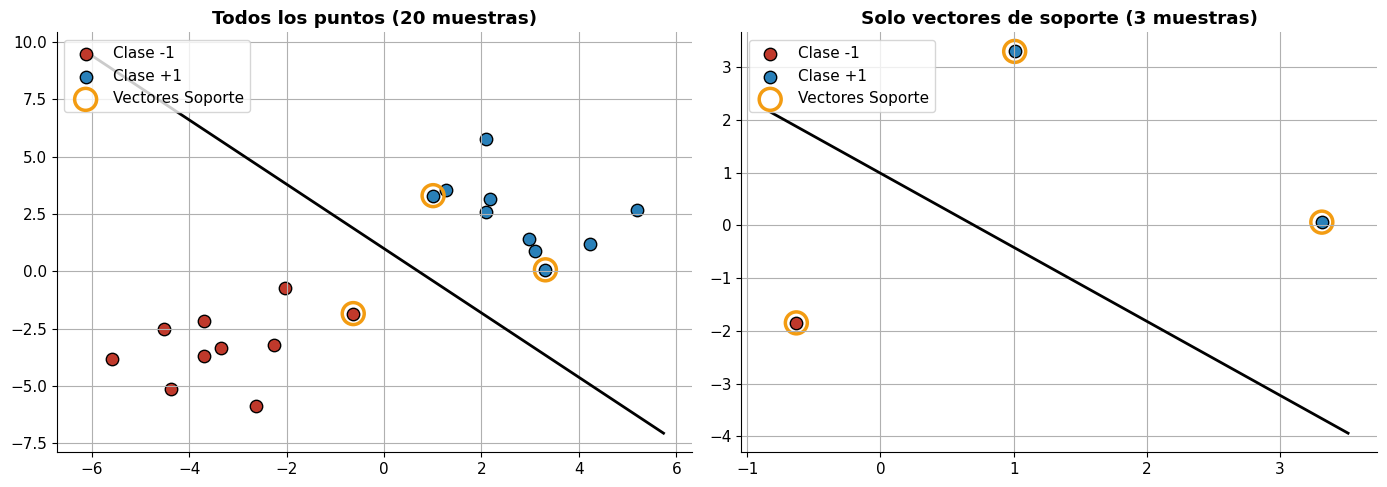

In [4]:
# Demostración: eliminar puntos no-soporte no cambia la frontera
np.random.seed(42)

# Generamos dataset con 20 puntos
X_disp = np.random.randn(20, 2) * 1.5
# Crear dos clusters separables
X_disp[:10] += np.array([-3, -3])
X_disp[10:] += np.array([3, 3])
y_disp = np.array([-1]*10 + [1]*10)

# SVM original
clf_orig = SVC(kernel='linear', C=1000)
clf_orig.fit(X_disp, y_disp)
n_sv_orig = len(clf_orig.support_)

# Eliminar puntos que NO son vectores de soporte
mask_keep = np.zeros(len(X_disp), dtype=bool)
mask_keep[clf_orig.support_] = True
X_reduced = X_disp[mask_keep]
y_reduced = y_disp[mask_keep]

# SVM en el conjunto reducido
clf_reduced = SVC(kernel='linear', C=1000)
clf_reduced.fit(X_reduced, y_reduced)

print(f"=== Demostración de Dispersión SVM ===")
print(f"Puntos originales: {len(X_disp)}")
print(f"Vectores de soporte: {n_sv_orig}")
print(f"Puntos no-soporte eliminados: {len(X_disp) - n_sv_orig}")
print(f"\nComparación de pesos:")
print(f"  w original:  {clf_orig.coef_[0]}")
print(f"  w reducido:  {clf_reduced.coef_[0]}")
print(f"  Diferencia:  {np.linalg.norm(clf_orig.coef_[0] - clf_reduced.coef_[0]):.2e}")
print(f"\n\\textbf{{La frontera es prácticamente idéntica. Los puntos no-soporte no importan.}}")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (X_plot, y_plot, clf, title) in zip(axes, [
    (X_disp, y_disp, clf_orig, f'Todos los puntos ({len(X_disp)} muestras)'),
    (X_reduced, y_reduced, clf_reduced, f'Solo vectores de soporte ({len(X_reduced)} muestras)')
]):
    ax.scatter(X_plot[y_plot==-1, 0], X_plot[y_plot==-1, 1], c='#C0392B', s=80, edgecolor='k', label='Clase -1')
    ax.scatter(X_plot[y_plot==1, 0], X_plot[y_plot==1, 1], c='#2980B9', s=80, edgecolor='k', label='Clase +1')
    
    # Frontera
    w = clf.coef_[0]; b = clf.intercept_[0]
    xlim = ax.get_xlim()
    xx = np.linspace(xlim[0], xlim[1], 100)
    yy = -(w[0]*xx + b)/w[1]
    ax.plot(xx, yy, 'k-', linewidth=2)
    
    # Vectores de soporte
    ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
               s=250, facecolors='none', edgecolors='#F39C12', linewidths=2.5, label='Vectores Soporte')
    ax.set_title(title, fontweight='bold')
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

## 1.4 Ejemplo numérico original: Detección de spam

**Escenario:** Detección de correos spam con 2 características:
- $x_1$: número de enlaces en el correo
- $x_2$: número de palabras sospechosas ("gratis", "urgente", "premio")

| Correo | $x_1$ (enlaces) | $x_2$ (palabras) | Etiqueta |
|--------|----------------|------------------|----------|
| A | 1 | 1 | Spam (+1) |
| B | 3 | 2 | Spam (+1) |
| C | 1 | 4 | No spam (-1) |
| D | 4 | 5 | No spam (-1) |

=== SVM entrenado para detección de spam ===

Vector de pesos w: [ 0.24976 -0.75024]
Sesgo b: 1.7515
Vectores de soporte: correos ['C', 'D', 'B']

Correo nuevo con x1=2, x2=3:
  Predicción: SPAM
  Valor de decisión: 0.0003
  |decision| cercano a 0 significa 'poca confianza'


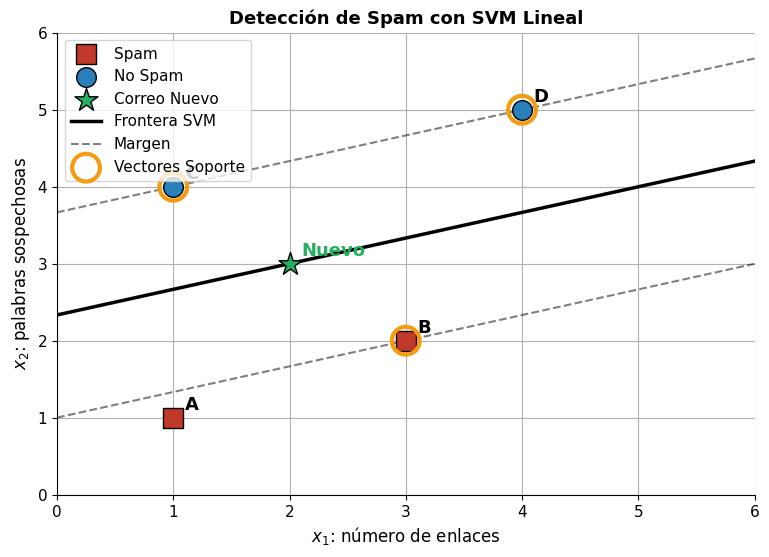


\textbf{Observación:} El correo nuevo tiene valor de decisión cercano a 0,
lo que indica que SVM 'no está seguro' de su clasificación.


In [5]:
# Dataset de spam
X_spam = np.array([[1, 1], [3, 2], [1, 4], [4, 5]])
y_spam = np.array([1, 1, -1, -1])
correos = ['A', 'B', 'C', 'D']

# Entrenar SVM
clf_spam = SVC(kernel='linear', C=1000)
clf_spam.fit(X_spam, y_spam)

print("=== SVM entrenado para detección de spam ===\n")
print(f"Vector de pesos w: {clf_spam.coef_[0]}")
print(f"Sesgo b: {clf_spam.intercept_[0]:.4f}")
print(f"Vectores de soporte: correos {[correos[i] for i in clf_spam.support_]}")

# Predicción de un correo nuevo
correo_nuevo = np.array([[2, 3]])
pred = clf_spam.predict(correo_nuevo)[0]
decision = clf_spam.decision_function(correo_nuevo)[0]
print(f"\nCorreo nuevo con x1=2, x2=3:")
print(f"  Predicción: {'SPAM' if pred == 1 else 'NO SPAM'}")
print(f"  Valor de decisión: {decision:.4f}")
print(f"  |decision| cercano a 0 significa 'poca confianza'")

# Visualización
plt.figure(figsize=(9, 6))
plt.scatter(X_spam[y_spam==1, 0], X_spam[y_spam==1, 1], c='#C0392B', s=200, marker='s', edgecolor='k', label='Spam', zorder=3)
plt.scatter(X_spam[y_spam==-1, 0], X_spam[y_spam==-1, 1], c='#2980B9', s=200, marker='o', edgecolor='k', label='No Spam', zorder=3)
plt.scatter(correo_nuevo[0, 0], correo_nuevo[0, 1], c='#27AE60', s=300, marker='*', edgecolor='k', label='Correo Nuevo', zorder=4)

for i, nombre in enumerate(correos):
    plt.annotate(nombre, (X_spam[i, 0]+0.1, X_spam[i, 1]+0.1), fontsize=13, fontweight='bold')
plt.annotate('Nuevo', (correo_nuevo[0, 0]+0.1, correo_nuevo[0, 1]+0.1), fontsize=13, fontweight='bold', color='#27AE60')

# Frontera
w = clf_spam.coef_[0]; b = clf_spam.intercept_[0]
xx = np.linspace(0, 6, 100)
yy = -(w[0]*xx + b)/w[1]
plt.plot(xx, yy, 'k-', linewidth=2.5, label='Frontera SVM')

# Márgenes
margin = 1/np.linalg.norm(w)
yy_up = yy + margin*np.sqrt(1 + (w[0]/w[1])**2)
yy_down = yy - margin*np.sqrt(1 + (w[0]/w[1])**2)
plt.plot(xx, yy_up, 'k--', alpha=0.5, label='Margen')
plt.plot(xx, yy_down, 'k--', alpha=0.5)

# Vectores de soporte
plt.scatter(clf_spam.support_vectors_[:, 0], clf_spam.support_vectors_[:, 1],
            s=400, facecolors='none', edgecolors='#F39C12', linewidths=3, zorder=5, label='Vectores Soporte')

plt.xlabel('$x_1$: número de enlaces', fontsize=12)
plt.ylabel('$x_2$: palabras sospechosas', fontsize=12)
plt.title('Detección de Spam con SVM Lineal', fontweight='bold', fontsize=13)
plt.legend(loc='upper left', fontsize=11)
plt.xlim(0, 6); plt.ylim(0, 6)
plt.show()

print("\n\\textbf{Observación:} El correo nuevo tiene valor de decisión cercano a 0,")
print("lo que indica que SVM 'no está seguro' de su clasificación.")

---
# Parte 2: El Truco del Kernel — Poder No Lineal sin Costo Extra

## 2.1 El problema de la no linealidad

En muchos casos reales, los datos **no son separables por una línea recta**. Por ejemplo, aprobar o no aprobar un curso puede depender de una combinación no lineal de dos parciales.

**Solución ingenua:** Mapear los datos a un espacio de mayor dimensión donde sí sean separables.

**Solución elegante:** Usar un **kernel**.

## 2.2 La ecuación del kernel

Un kernel $K(\mathbf{x}_i, \mathbf{x}_j)$ calcula **la similitud entre dos puntos** como si estuvieran en un espacio de dimensión superior, **sin calcular el mapeo explícitamente**:

$$K(\mathbf{x}_i, \mathbf{x}_j) = \phi(\mathbf{x}_i)^\top \phi(\mathbf{x}_j)$$

Donde $\phi$ es el mapeo a dimensión superior.

**El insight matemático:** El algoritmo de SVM solo necesita **productos punto** entre puntos. Si podemos calcular esos productos sin construir $\phi$, ganamos poder expresivo sin costo computacional.

In [6]:
# Verificación simbólica del kernel polinomial
print("=== Verificación Simbólica: Kernel Polinomial ===\n")

x1, x2, z1, z2 = sp.symbols('x_1 x_2 z_1 z_2', real=True)
x_vec = Matrix([x1, x2])
z_vec = Matrix([z1, z2])

# Kernel polinomial de grado 2: (x^T z)^2
K_poly = ((x_vec.T * z_vec)[0,0])**2
print("K(x, z) = (x^T z)^2:")
display(sp.expand(K_poly))

# Mapeo phi(x) explicito
phi_x = Matrix([x1**2, sp.sqrt(2)*x1*x2, x2**2])
phi_z = Matrix([z1**2, sp.sqrt(2)*z1*z2, z2**2])

# Producto punto en el espacio de caracteristicas
phi_product = (phi_x.T * phi_z)[0,0]
print("\nφ(x)^T φ(z) con φ = (x1^2, √2·x1·x2, x2^2):")
display(sp.expand(phi_product))

# Diferencia
diferencia = sp.simplify(K_poly - phi_product)
print(f"\nDiferencia K(x, z) - φ(x)^T φ(z) = {diferencia}")
print("\n\\textbf{¡El kernel reproduce exactamente el producto punto en el espacio mapeado!}")

=== Verificación Simbólica: Kernel Polinomial ===

K(x, z) = (x^T z)^2:


  2   2                     2   2
x₁ ⋅z₁  + 2⋅x₁⋅x₂⋅z₁⋅z₂ + x₂ ⋅z₂ 


φ(x)^T φ(z) con φ = (x1^2, √2·x1·x2, x2^2):


  2   2                     2   2
x₁ ⋅z₁  + 2⋅x₁⋅x₂⋅z₁⋅z₂ + x₂ ⋅z₂ 


Diferencia K(x, z) - φ(x)^T φ(z) = 0

\textbf{¡El kernel reproduce exactamente el producto punto en el espacio mapeado!}


## 2.3 Ejemplo original: Predicción de aprobación con dos parciales

**Escenario:** Un curso con dos parciales. La regla de aprobación es:
- Aprobar si **al menos un parcial es mayor o igual a 7**
- Esto genera una frontera **no lineal** en el espacio $(x_1, x_2)$

| Estudiante | Parcial 1 | Parcial 2 | Aprobó |
|-----------|-----------|-----------|--------|
| E1 | 8 | 9 | Sí (+1) |
| E2 | 3 | 4 | No (-1) |
| E3 | 2 | 9 | Sí (+1) |
| E4 | 9 | 2 | Sí (+1) |
| E5 | 5 | 5 | No (-1) |
| E6 | 6 | 6 | No (-1) |
| E7 | 8 | 3 | Sí (+1) |
| E8 | 3 | 8 | Sí (+1) |

=== Comparación de Kernels ===

SVM Lineal - Accuracy en entrenamiento: 75.0%
SVM RBF    - Accuracy en entrenamiento: 100.0%


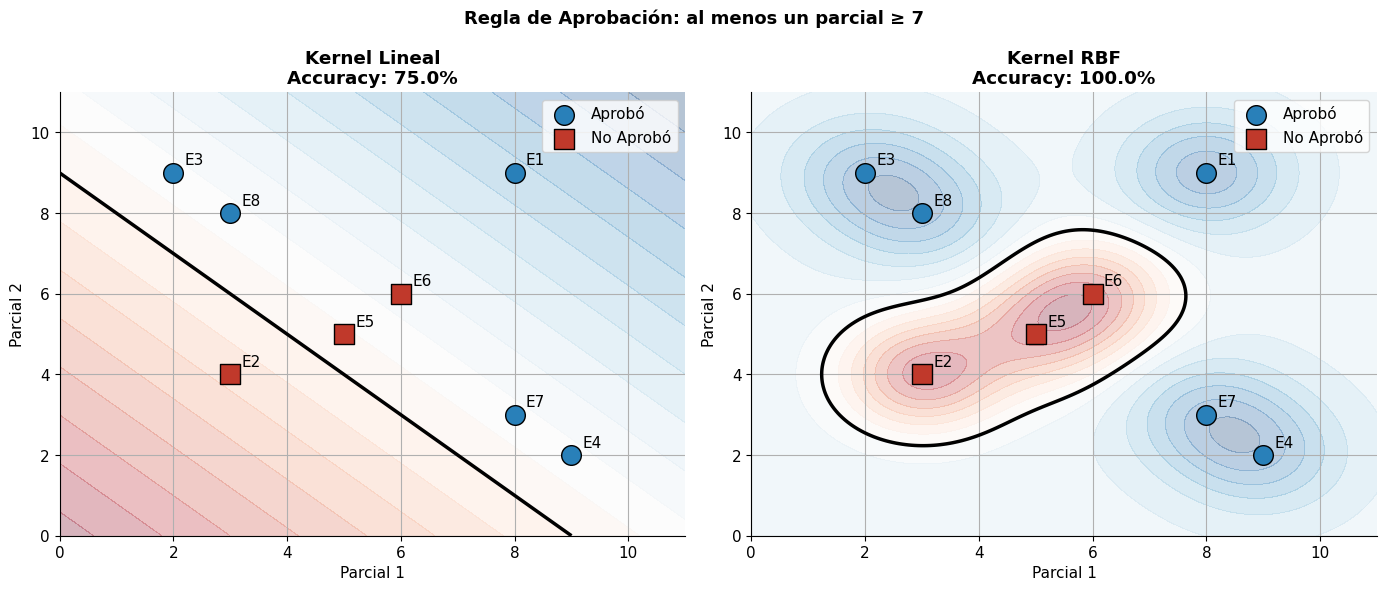


\textbf{Observación:} El kernel RBF captura correctamente la regla no lineal,
mientras que el kernel lineal falla en capturar la estructura 'OR' de la decisión.


In [7]:
# Dataset de aprobación con regla no lineal
X_aprob = np.array([
    [8, 9], [3, 4], [2, 9], [9, 2],
    [5, 5], [6, 6], [8, 3], [3, 8]
])
y_aprob = np.array([1, -1, 1, 1, -1, -1, 1, 1])
nombres = ['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8']

# Comparación: SVM lineal vs SVM con kernel RBF
clf_linear = SVC(kernel='linear', C=10)
clf_linear.fit(X_aprob, y_aprob)

clf_rbf = SVC(kernel='rbf', C=10, gamma=0.5)
clf_rbf.fit(X_aprob, y_aprob)

acc_lin = clf_linear.score(X_aprob, y_aprob)
acc_rbf = clf_rbf.score(X_aprob, y_aprob)

print("=== Comparación de Kernels ===\n")
print(f"SVM Lineal - Accuracy en entrenamiento: {acc_lin*100:.1f}%")
print(f"SVM RBF    - Accuracy en entrenamiento: {acc_rbf*100:.1f}%")

# Visualización: comparación de fronteras
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

xx, yy = np.meshgrid(np.linspace(0, 11, 200), np.linspace(0, 11, 200))

for ax, (clf, title) in zip(axes, [(clf_linear, 'Kernel Lineal'), (clf_rbf, 'Kernel RBF')]):
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.3)
    ax.contour(xx, yy, Z, levels=[0], colors='black', linewidths=2.5)
    
    ax.scatter(X_aprob[y_aprob==1, 0], X_aprob[y_aprob==1, 1],
               c='#2980B9', s=200, edgecolor='k', label='Aprobó', zorder=3)
    ax.scatter(X_aprob[y_aprob==-1, 0], X_aprob[y_aprob==-1, 1],
               c='#C0392B', s=200, marker='s', edgecolor='k', label='No Aprobó', zorder=3)
    
    for i, nombre in enumerate(nombres):
        ax.annotate(nombre, (X_aprob[i, 0]+0.2, X_aprob[i, 1]+0.2), fontsize=11)
    
    ax.set_title(f'{title}\nAccuracy: {clf.score(X_aprob, y_aprob)*100:.1f}%', fontweight='bold')
    ax.set_xlabel('Parcial 1'); ax.set_ylabel('Parcial 2')
    ax.legend(loc='upper right')
    ax.set_xlim(0, 11); ax.set_ylim(0, 11)

plt.suptitle('Regla de Aprobación: al menos un parcial ≥ 7', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print("\n\\textbf{Observación:} El kernel RBF captura correctamente la regla no lineal,")
print("mientras que el kernel lineal falla en capturar la estructura 'OR' de la decisión.")

## 2.4 Los tres kernels que debes conocer

| Kernel | Intuición | Cuándo usarlo |
|--------|-----------|---------------|
| **Lineal** | Frontera recta | Datos ya separables linealmente |
| **Polinomial** | Fronteras curvas suaves | Datos con interacciones entre características |
| **RBF (Gaussiano)** | Fronteras muy flexibles | **Por defecto**, funciona en la mayoría de casos |

El kernel **RBF** es el más poderoso porque tiene un hiperparámetro $\gamma$ que controla qué tan "local" es la decisión.

---
# Parte 3: SVR — Regresión Robusta con Tubo ε

## 3.1 La idea central

SVM clasifica (predice etiquetas). ¿Y si queremos predecir un **número** (como la nota final)?

SVR (Support Vector Regression) adapta la misma idea: en lugar de buscar una frontera que separe clases, busca una **función que se ajuste a los datos**, tolerando errores pequeños.

## 3.2 El tubo de tolerancia ε

La idea revolucionaria de SVR es el **tubo $\varepsilon$-insensible**: si la predicción está dentro de una banda de ancho $2\varepsilon$ alrededor del valor real, **no hay penalización**:

$$\text{Pérdida} = \max(0, |y - f(\mathbf{x})| - \varepsilon)$$

**Intuición:** Es como pedirle a un estudiante que estime su nota con un margen de error aceptable. Si acierta dentro de $\pm \varepsilon$, está bien. Solo penalizamos errores grandes.

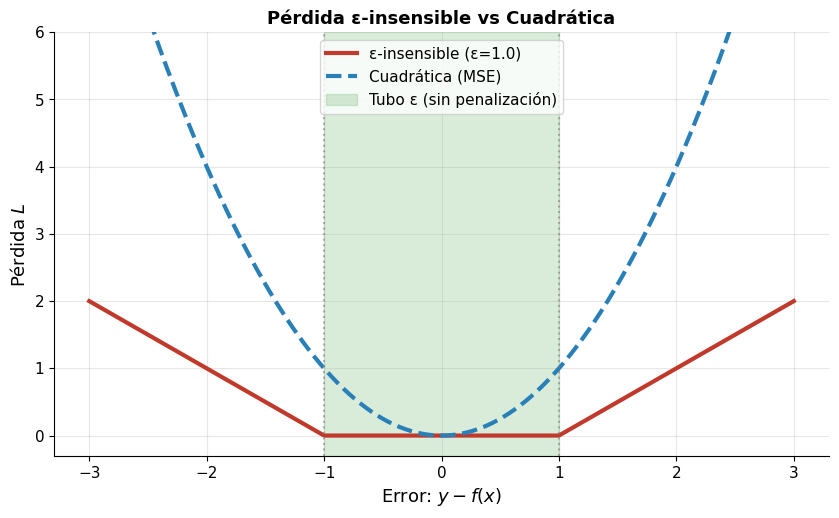

\textbf{Observaciones clave:}
- Dentro del tubo |y - f| <= ε: pérdida CERO (SVR ignora esos puntos)
- Fuera del tubo: pérdida LINEAL (no cuadrática), por eso SVR es robusto a outliers
- La pérdida cuadrática penaliza mucho más los errores grandes


In [8]:
# Visualización de la pérdida ε-insensible vs cuadrática
e = np.linspace(-3, 3, 500)
eps_val = 1.0

L_epsilon = np.maximum(0, np.abs(e) - eps_val)
L_cuadratica = e**2

plt.figure(figsize=(10, 5.5))
plt.plot(e, L_epsilon, linewidth=3, label=f'ε-insensible (ε={eps_val})', color='#C0392B')
plt.plot(e, L_cuadratica, linewidth=3, linestyle='--', label='Cuadrática (MSE)', color='#2980B9')
plt.axvline(x=eps_val, color='gray', linestyle=':', alpha=0.6)
plt.axvline(x=-eps_val, color='gray', linestyle=':', alpha=0.6)
plt.axvspan(-eps_val, eps_val, alpha=0.15, color='green', label='Tubo ε (sin penalización)')
plt.xlabel(r'Error: $y - f(x)$', fontsize=13)
plt.ylabel(r'Pérdida $L$', fontsize=13)
plt.title('Pérdida ε-insensible vs Cuadrática', fontweight='bold', fontsize=13)
plt.legend(fontsize=11)
plt.ylim(-0.3, 6)
plt.grid(alpha=0.3)
plt.show()

print("\\textbf{Observaciones clave:}")
print("- Dentro del tubo |y - f| <= ε: pérdida CERO (SVR ignora esos puntos)")
print("- Fuera del tubo: pérdida LINEAL (no cuadrática), por eso SVR es robusto a outliers")
print("- La pérdida cuadrática penaliza mucho más los errores grandes")

## 3.3 Ventaja sobre Regresión Lineal

| Aspecto | Regresión Lineal | SVR |
|---------|------------------|-----|
| Sensibilidad a outliers | Muy sensible (error cuadrático) | Robusta (error lineal) |
| Frontera | Siempre lineal | Puede ser no lineal (kernel) |
| Sobreajuste | Tiende a ajustar todos los puntos | Ignora puntos dentro del tubo |
| Vectores de soporte | No aplica | Solo puntos fuera del tubo |

## 3.4 Ejemplo numérico original: Nota final vs horas de trabajo

**Escenario:** Predecir la nota final de un proyecto basándose en las horas de trabajo semanales. Algunos grupos reportan horas poco realistas (outliers).

| Grupo | Horas | Nota real |
|-------|-------|-----------|
| G1 | 10 | 6.0 |
| G2 | 20 | 7.5 |
| G3 | 5 | 3.0 |
| G4 | 30 | 9.0 |
| G5 | 15 | 8.5 |
| G6 | 25 | 7.0 |
| **G7** | **50** | **2.0** | ← Outlier: muchas horas pero nota baja

=== SVR para predicción de notas ===

Número de vectores de soporte: 5
Vectores de soporte: ['G3', 'G4', 'G5', 'G6', 'G7']


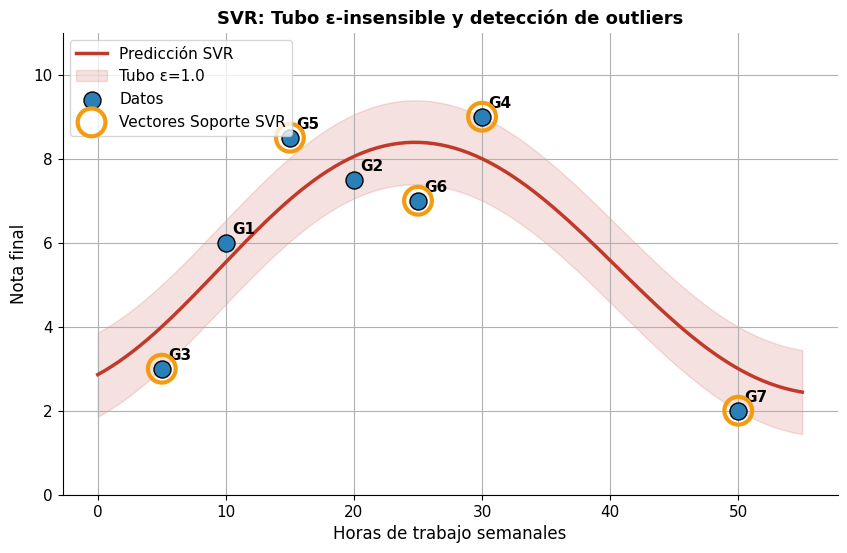


\textbf{Observación crítica:}
El Grupo G7 (50 horas, nota 2) es un OUTLIER:
  - En regresión lineal, esto distorsionaría la pendiente completamente
  - En SVR, G7 queda fuera del tubo y se convierte en vector de soporte,
    pero NO arrastra la curva de predicción hacia abajo.


In [9]:
# Dataset con un outlier
X_horas = np.array([[10], [20], [5], [30], [15], [25], [50]], dtype=float)
y_notas = np.array([6.0, 7.5, 3.0, 9.0, 8.5, 7.0, 2.0])
grupos = ['G1', 'G2', 'G3', 'G4', 'G5', 'G6', 'G7']

# Escalar (importante para SVR)
scaler = StandardScaler()
X_horas_scaled = scaler.fit_transform(X_horas)

# Entrenar SVR con RBF y epsilon=1.0
svr = SVR(kernel='rbf', C=10, epsilon=1.0, gamma=0.5)
svr.fit(X_horas_scaled, y_notas)

print("=== SVR para predicción de notas ===\n")
print(f"Número de vectores de soporte: {len(svr.support_)}")
print(f"Vectores de soporte: {[grupos[i] for i in svr.support_]}")

# Visualización con tubo
fig, ax = plt.subplots(figsize=(10, 6))

# Curva de predicción
X_plot = np.linspace(0, 55, 200).reshape(-1, 1)
X_plot_scaled = scaler.transform(X_plot)
y_plot = svr.predict(X_plot_scaled)

ax.plot(X_plot, y_plot, color='#C0392B', linewidth=2.5, label='Predicción SVR', zorder=2)
ax.fill_between(X_plot.ravel(), y_plot - 1.0, y_plot + 1.0, color='#C0392B', alpha=0.15, label='Tubo ε=1.0', zorder=1)

# Puntos
ax.scatter(X_horas, y_notas, c='#2980B9', s=150, edgecolor='k', zorder=3, label='Datos')
for i, g in enumerate(grupos):
    ax.annotate(g, (X_horas[i, 0]+0.5, y_notas[i]+0.2), fontsize=11, fontweight='bold')

# Destacar vectores de soporte
sv_X = X_horas[svr.support_]
sv_y = y_notas[svr.support_]
ax.scatter(sv_X, sv_y, s=400, facecolors='none', edgecolors='#F39C12', linewidths=3, zorder=4, label='Vectores Soporte SVR')

ax.set_xlabel('Horas de trabajo semanales', fontsize=12)
ax.set_ylabel('Nota final', fontsize=12)
ax.set_title('SVR: Tubo ε-insensible y detección de outliers', fontweight='bold', fontsize=13)
ax.legend(fontsize=11, loc='upper left')
ax.set_ylim(0, 11)
plt.show()

print("\n\\textbf{Observación crítica:}")
print("El Grupo G7 (50 horas, nota 2) es un OUTLIER:")
print("  - En regresión lineal, esto distorsionaría la pendiente completamente")
print("  - En SVR, G7 queda fuera del tubo y se convierte en vector de soporte,")
print("    pero NO arrastra la curva de predicción hacia abajo.")

## 3.5 Comparación numérica: Regresión Lineal vs SVR

Verifiquemos cuantitativamente cuánto afecta el outlier a cada modelo.

In [10]:
from sklearn.linear_model import LinearRegression

# Comparación: con y sin el outlier
# Dataset sin el outlier (G7)
X_sin_outlier = X_horas[:-1]
y_sin_outlier = y_notas[:-1]

# Dataset con outlier
X_con_outlier = X_horas
y_con_outlier = y_notas

# Escalar ambos
scaler_sin = StandardScaler().fit(X_sin_outlier)
scaler_con = StandardScaler().fit(X_con_outlier)
X_sin_s = scaler_sin.transform(X_sin_outlier)
X_con_s = scaler_con.transform(X_con_outlier)

# Regresión Lineal
lr_sin = LinearRegression().fit(X_sin_s, y_sin_outlier)
lr_con = LinearRegression().fit(X_con_s, y_con_outlier)

# SVR
svr_sin = SVR(kernel='rbf', C=10, epsilon=1.0, gamma=0.5).fit(X_sin_s, y_sin_outlier)
svr_con = SVR(kernel='rbf', C=10, epsilon=1.0, gamma=0.5).fit(X_con_s, y_con_outlier)

# Predicciones en un punto intermedio (25 horas)
punto_test = scaler_sin.transform([[25]])
punto_test_con = scaler_con.transform([[25]])

print("=== Comparación: Predicción a 25 horas ===\n")
print(f"Regresión Lineal:")
print(f"  Sin outlier: {lr_sin.predict(punto_test)[0]:.2f}")
print(f"  Con outlier: {lr_con.predict(punto_test_con)[0]:.2f}")
print(f"  Diferencia:  {abs(lr_sin.predict(punto_test)[0] - lr_con.predict(punto_test_con)[0]):.2f}\n")

print(f"SVR:")
print(f"  Sin outlier: {svr_sin.predict(punto_test)[0]:.2f}")
print(f"  Con outlier: {svr_con.predict(punto_test_con)[0]:.2f}")
print(f"  Diferencia:  {abs(svr_sin.predict(punto_test)[0] - svr_con.predict(punto_test_con)[0]):.2f}\n")

print("\\textbf{Conclusión:} La regresión lineal es más afectada por el outlier que SVR.")

=== Comparación: Predicción a 25 horas ===

Regresión Lineal:
  Sin outlier: 8.20
  Con outlier: 6.03
  Diferencia:  2.18

SVR:
  Sin outlier: 8.00
  Con outlier: 8.39
  Diferencia:  0.39

\textbf{Conclusión:} La regresión lineal es más afectada por el outlier que SVR.


---
# Parte 4: Ajuste de Hiperparámetros — La Clave del Éxito

## 4.1 Los dos hiperparámetros críticos

Todo SVM/SVR depende fundamentalmente de dos parámetros:

**$C$ (parámetro de regularización):**
- $C$ grande = penaliza fuertemente los errores = margen estrecho = **sobreajuste**
- $C$ pequeño = tolera errores = margen ancho = **subajuste**

**$\gamma$ (ancho del kernel RBF):**
- $\gamma$ grande = cada punto influye solo localmente = **sobreajuste**
- $\gamma$ pequeño = influencia global = **subajuste**

> **Analogía:** $C$ es "qué tan estricto es el profesor", $\gamma$ es "qué tan detallado es el análisis de cada estudiante".

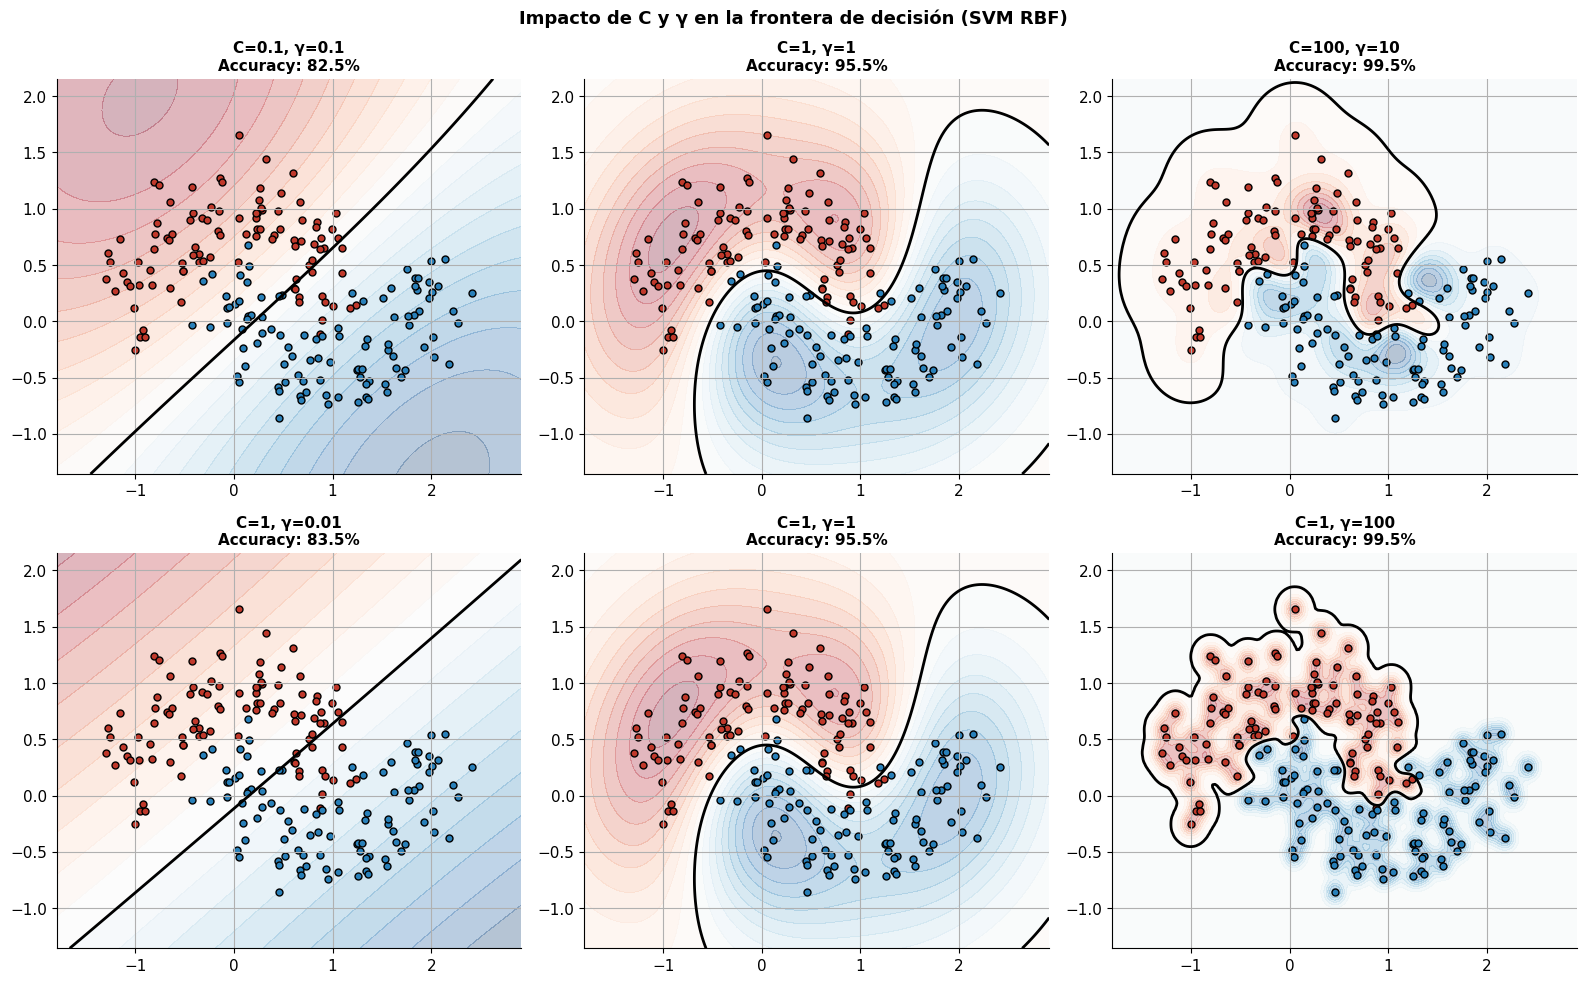

\textbf{Observaciones:}
- Fila superior: variando C con γ=1
  * C=0.1: frontera demasiado suave (subajuste)
  * C=100, γ=10: frontera muy irregular (sobreajuste)
- Fila inferior: variando γ con C=1
  * γ=0.01: frontera casi lineal (subajuste)
  * γ=100: frontera extremadamente local (sobreajuste)


In [11]:
# Visualización del impacto de C y gamma en la frontera de decisión
np.random.seed(2026)
X_moons, y_moons = make_moons(n_samples=200, noise=0.25, random_state=2026)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

configs = [
    (0.1, 0.1), (1, 1), (100, 10),      # Variando C con gamma fijo
    (1, 0.01), (1, 1), (1, 100)        # Variando gamma con C fijo
]

xx, yy = np.meshgrid(np.linspace(X_moons[:,0].min()-0.5, X_moons[:,0].max()+0.5, 200),
                     np.linspace(X_moons[:,1].min()-0.5, X_moons[:,1].max()+0.5, 200))

for ax, (C_val, gamma_val) in zip(axes.ravel(), configs):
    clf = SVC(kernel='rbf', C=C_val, gamma=gamma_val)
    clf.fit(X_moons, y_moons)
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.3)
    ax.contour(xx, yy, Z, levels=[0], colors='black', linewidths=2)
    ax.scatter(X_moons[y_moons==0, 0], X_moons[y_moons==0, 1], c='#C0392B', s=25, edgecolor='k')
    ax.scatter(X_moons[y_moons==1, 0], X_moons[y_moons==1, 1], c='#2980B9', s=25, edgecolor='k')
    acc = clf.score(X_moons, y_moons)
    ax.set_title(f'C={C_val}, γ={gamma_val}\nAccuracy: {acc*100:.1f}%', fontweight='bold', fontsize=11)

plt.suptitle('Impacto de C y γ en la frontera de decisión (SVM RBF)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print("\\textbf{Observaciones:}")
print("- Fila superior: variando C con γ=1")
print("  * C=0.1: frontera demasiado suave (subajuste)")
print("  * C=100, γ=10: frontera muy irregular (sobreajuste)")
print("- Fila inferior: variando γ con C=1")
print("  * γ=0.01: frontera casi lineal (subajuste)")
print("  * γ=100: frontera extremadamente local (sobreajuste)")

## 4.2 Grid Search con Validación Cruzada

El método estándar es:
1. Definir una grilla de valores para $C$ y $\gamma$
2. Para cada combinación, hacer **$k$-fold cross-validation**
3. Elegir la combinación con mejor desempeño promedio
4. Evaluar en el conjunto de prueba

**¿Por qué validación cruzada y no solo un train/test split?** Porque la partición única puede ser afortunada o desafortunada. La CV promedia sobre múltiples particiones, dando una estimación más robusta.

In [12]:
# Ejemplo numérico original: comparación de configuraciones
# Dataset: predicción de aprobación con 3 características académicas sintéticas
np.random.seed(2026)

# Generamos datos sintéticos académicos
n_samples = 500
X_acad = np.random.randn(n_samples, 3) * 2 + [5, 6, 7]
# Regla de aprobación: combinación lineal + ruido
logits = 0.8*X_acad[:, 0] + 0.5*X_acad[:, 1] + 0.3*X_acad[:, 2] - 8
probs = 1/(1 + np.exp(-logits))
y_acad = (np.random.rand(n_samples) < probs).astype(int)

print(f"Dataset académico: {n_samples} estudiantes, 3 características")
print(f"Tasa de aprobación: {y_acad.mean()*100:.1f}%\n")

# Split
X_tr, X_te, y_tr, y_te = train_test_split(X_acad, y_acad, test_size=0.3, random_state=2026, stratify=y_acad)

# Pipeline
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf'))
])

# Grid Search
param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': [0.001, 0.01, 0.1, 1]
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_tr, y_tr)

print("=== Resultados de GridSearchCV ===\n")
print(f"Mejor configuración: {grid.best_params_}")
print(f"Mejor accuracy en CV: {grid.best_score_*100:.2f}%")
print(f"Accuracy en test: {grid.score(X_te, y_te)*100:.2f}%")

Dataset académico: 500 estudiantes, 3 características
Tasa de aprobación: 68.0%

=== Resultados de GridSearchCV ===

Mejor configuración: {'svm__C': 10, 'svm__gamma': 0.01}
Mejor accuracy en CV: 80.00%
Accuracy en test: 81.33%


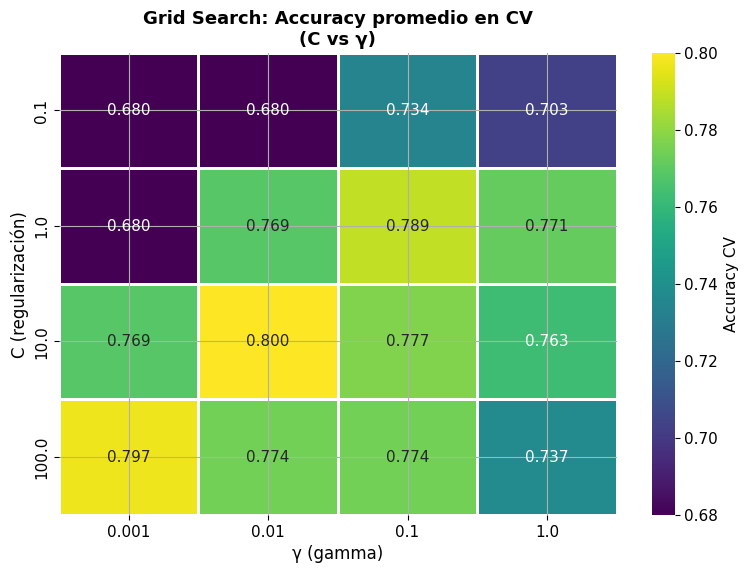

\textbf{Observaciones del mapa de calor:}
- Los valores bajos de C con gamma moderado dan buen resultado
- C muy grande con gamma grande: sobreajuste (menor accuracy en CV)
- C muy chico con gamma muy chico: subajuste (menor accuracy en CV)


In [13]:
# Mapa de calor de la grilla
results = pd.DataFrame(grid.cv_results_)
pivot = results.pivot(index='param_svm__C', columns='param_svm__gamma', values='mean_test_score')

plt.figure(figsize=(9, 6))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='viridis',
            cbar_kws={'label': 'Accuracy CV'}, linewidths=1)
plt.title('Grid Search: Accuracy promedio en CV\n(C vs γ)', fontweight='bold', fontsize=13)
plt.xlabel('γ (gamma)', fontsize=12)
plt.ylabel('C (regularización)', fontsize=12)
plt.show()

print("\\textbf{Observaciones del mapa de calor:}")
print("- Los valores bajos de C con gamma moderado dan buen resultado")
print("- C muy grande con gamma grande: sobreajuste (menor accuracy en CV)")
print("- C muy chico con gamma muy chico: subajuste (menor accuracy en CV)")

---
# Parte 5: SVD — La Navaja Suiza del Análisis de Datos

## 5.1 La idea central

**SVD (Descomposición en Valores Singulares)** descompone cualquier matriz en tres partes que revelan su **estructura oculta**:

$$\mathbf{A} = \mathbf{U} \boldsymbol{\Sigma} \mathbf{V}^\top$$

- $\mathbf{U}$: direcciones importantes en el espacio de **salida**
- $\boldsymbol{\Sigma}$: **importancia** de cada dirección (valores singulares)
- $\mathbf{V}$: direcciones importantes en el espacio de **entrada**

> **Analogía:** Es como descomponer una canción en sus notas fundamentales. La mayoría de la información está en las primeras notas; el resto son matices.

## 5.2 La propiedad que lo cambia todo

Los valores singulares están **ordenados de mayor a menor importancia**. La mayoría del "contenido" de la matriz está concentrado en los primeros valores singulares.

Esto permite **aproximar la matriz** con solo $r$ componentes:

$$\mathbf{A} \approx \mathbf{A}_r = \sum_{k=1}^{r} \sigma_k \mathbf{u}_k \mathbf{v}_k^\top$$

**Teorema de Eckart-Young:** Esta es la **mejor aproximación posible** de rango $r$ en el sentido de mínimos cuadrados.

In [14]:
# Ejemplo numérico original: SVD en datos académicos
# 5 variables académicas por estudiante
np.random.seed(2026)
n_est = 300

# Variable latente: 'rendimiento general'
rendimiento = np.random.randn(n_est)

# Las 5 variables observadas se generan a partir de la latente + ruido
X_acad_5d = np.column_stack([
    rendimiento * 1.5 + np.random.randn(n_est) * 0.3,   # Nota parcial 1
    rendimiento * 1.3 + np.random.randn(n_est) * 0.4,   # Nota parcial 2
    rendimiento * 1.1 + np.random.randn(n_est) * 0.5,   # Horas de estudio
    rendimiento * 0.9 + np.random.randn(n_est) * 0.6,   # Asistencia
    rendimiento * 0.7 + np.random.randn(n_est) * 0.7    # Participación
]) * 2 + 5

variables = ['Parcial 1', 'Parcial 2', 'Horas estudio', 'Asistencia', 'Participación']
df_acad = pd.DataFrame(X_acad_5d, columns=variables)

print("=== Dataset Académico 5D ===")
print(df_acad.describe().round(2))

# Centramos
X_centered = X_acad_5d - X_acad_5d.mean(axis=0)

# SVD
U_svd, S_svd, Vt_svd = np.linalg.svd(X_centered, full_matrices=False)

print(f"\n=== Valores Singulares ===")
for k, s in enumerate(S_svd):
    print(f"  σ_{k+1} = {s:.2f}")

# Varianza explicada
var_exp = S_svd**2 / np.sum(S_svd**2)
var_acum = np.cumsum(var_exp)

print(f"\n=== Varianza Explicada ===")
for k in range(len(S_svd)):
    print(f"  Componente {k+1}: {var_exp[k]*100:.2f}%  (acumulada: {var_acum[k]*100:.2f}%)")

=== Dataset Académico 5D ===
       Parcial 1  Parcial 2  Horas estudio  Asistencia  Participación
count     300.00     300.00         300.00      300.00         300.00
mean        5.21       5.31           5.10        5.11           5.12
std         3.07       2.79           2.49        2.15           1.99
min        -5.53      -1.67          -0.64       -1.60          -2.32
25%         3.25       3.36           3.28        3.76           3.78
50%         5.44       5.48           5.08        5.14           5.03
75%         7.05       7.20           7.05        6.74           6.63
max        12.68      12.95          12.77       10.00           9.89

=== Valores Singulares ===
  σ_1 = 89.96
  σ_2 = 23.67
  σ_3 = 21.73
  σ_4 = 17.20
  σ_5 = 12.31

=== Varianza Explicada ===
  Componente 1: 84.54%  (acumulada: 84.54%)
  Componente 2: 5.85%  (acumulada: 90.39%)
  Componente 3: 4.93%  (acumulada: 95.33%)
  Componente 4: 3.09%  (acumulada: 98.42%)
  Componente 5: 1.58%  (acumulada: 100.00%

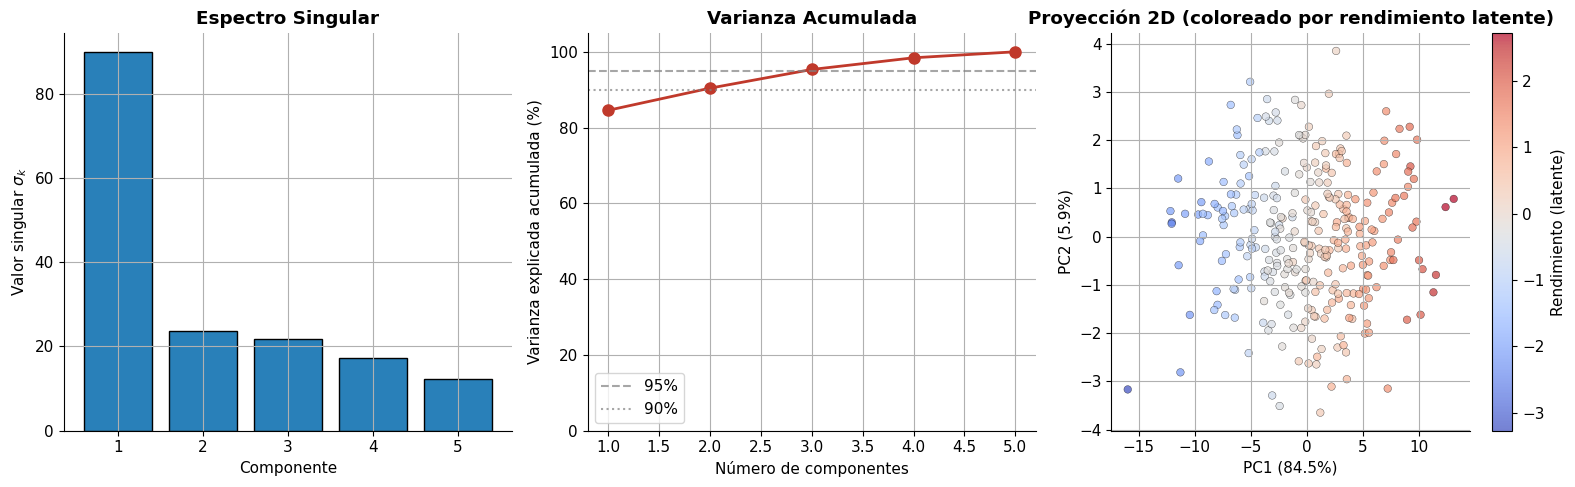

\textbf{Interpretación:}
PC1 captura 'rendimiento general' (todas las variables cargan positivamente)
PC2 captura diferencias específicas entre áreas
La proyección 2D preserva la estructura esencial de los datos


In [15]:
# Visualización de SVD
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Valores singulares
axes[0].bar(range(1, len(S_svd)+1), S_svd, color='#2980B9', edgecolor='k')
axes[0].set_xlabel('Componente', fontsize=11)
axes[0].set_ylabel('Valor singular $\\sigma_k$', fontsize=11)
axes[0].set_title('Espectro Singular', fontweight='bold')

# 2. Varianza explicada acumulada
axes[1].plot(range(1, len(S_svd)+1), var_acum*100, 'o-', color='#C0392B', linewidth=2, markersize=8)
axes[1].axhline(95, color='gray', linestyle='--', alpha=0.7, label='95%')
axes[1].axhline(90, color='gray', linestyle=':', alpha=0.7, label='90%')
axes[1].set_xlabel('Número de componentes', fontsize=11)
axes[1].set_ylabel('Varianza explicada acumulada (%)', fontsize=11)
axes[1].set_title('Varianza Acumulada', fontweight='bold')
axes[1].legend()
axes[1].set_ylim(0, 105)

# 3. Proyección 2D
Z_2d = X_centered @ Vt_svd.T[:, :2]
scatter = axes[2].scatter(Z_2d[:, 0], Z_2d[:, 1], c=rendimiento, cmap='coolwarm', s=30, alpha=0.7, edgecolor='k', linewidth=0.3)
axes[2].set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)', fontsize=11)
axes[2].set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)', fontsize=11)
axes[2].set_title('Proyección 2D (coloreado por rendimiento latente)', fontweight='bold')
plt.colorbar(scatter, ax=axes[2], label='Rendimiento (latente)')

plt.tight_layout()
plt.show()

print("\\textbf{Interpretación:}")
print("PC1 captura 'rendimiento general' (todas las variables cargan positivamente)")
print("PC2 captura diferencias específicas entre áreas")
print("La proyección 2D preserva la estructura esencial de los datos")

## 5.3 Verificación simbólica de las propiedades de SVD

Verifiquemos con SymPy que la SVD satisface sus propiedades fundamentales.

In [16]:
# Verificación simbólica: A^T A = V Σ² V^T
print("=== Verificación Algebraica de SVD ===\n")

a11, a12, a21, a22, a31, a32 = sp.symbols('a_{11} a_{12} a_{21} a_{22} a_{31} a_{32}', real=True)
A = Matrix([[a11, a12], [a21, a22], [a31, a32]])

print("Matriz A (3×2):")
display(A)

# A^T A
ATA = A.T * A
print("\nA^T A (2×2) - matriz simétrica:")
display(ATA)

# Traza de A^T A = suma de σ_i²
print("\nTraza(A^T A) = suma de valores singulares al cuadrado:")
display(sp.trace(ATA))

# Determinante de A^T A = producto de σ_i²
print("\nDet(A^T A) = producto de valores singulares al cuadrado:")
display(sp.simplify(ATA.det()))

print("\n\\textbf{Estas son propiedades fundamentales de SVD:}")
print("  sum(σ_i²) = traza(A^T A)")
print("  prod(σ_i²) = det(A^T A)")
print("Útiles para verificar cálculos numéricos y entender la estructura de A.")

=== Verificación Algebraica de SVD ===

Matriz A (3×2):


⎡a_{11}  a_{12}⎤
⎢              ⎥
⎢a_{21}  a_{22}⎥
⎢              ⎥
⎣a_{31}  a_{32}⎦


A^T A (2×2) - matriz simétrica:


⎡               2         2         2                                          ↪
⎢         a_{11}  + a_{21}  + a_{31}            a_{11}⋅a_{12} + a_{21}⋅a_{22}  ↪
⎢                                                                              ↪
⎢                                                              2         2     ↪
⎣a_{11}⋅a_{12} + a_{21}⋅a_{22} + a_{31}⋅a_{32}           a_{12}  + a_{22}  + a ↪

↪                ⎤
↪ + a_{31}⋅a_{32}⎥
↪                ⎥
↪      2         ⎥
↪ _{32}          ⎦


Traza(A^T A) = suma de valores singulares al cuadrado:


      2         2         2         2         2         2
a_{11}  + a_{12}  + a_{21}  + a_{22}  + a_{31}  + a_{32} 


Det(A^T A) = producto de valores singulares al cuadrado:


      2       2         2       2                                              ↪
a_{11} ⋅a_{22}  + a_{11} ⋅a_{32}  - 2⋅a_{11}⋅a_{12}⋅a_{21}⋅a_{22} - 2⋅a_{11}⋅a ↪

↪                             2       2         2       2         2       2    ↪
↪ _{12}⋅a_{31}⋅a_{32} + a_{12} ⋅a_{21}  + a_{12} ⋅a_{31}  + a_{21} ⋅a_{32}  -  ↪

↪                                       2       2
↪ 2⋅a_{21}⋅a_{22}⋅a_{31}⋅a_{32} + a_{22} ⋅a_{31} 


\textbf{Estas son propiedades fundamentales de SVD:}
  sum(σ_i²) = traza(A^T A)
  prod(σ_i²) = det(A^T A)
Útiles para verificar cálculos numéricos y entender la estructura de A.


## 5.4 Aproximación de rango bajo

El Teorema de Eckart-Young garantiza que truncar la SVD da la **mejor aproximación** posible en rango $r$.

---
# Parte 6: Síntesis Integradora — SVD + SVM en un Pipeline

## 6.1 La cadena lógica

```
SVD → Reducir dimensionalidad → SVM/SVR → Modelar y predecir
```

En problemas reales con muchas características, la combinación es poderosa:
1. **SVD** identifica las direcciones más informativas (elimina redundancia y ruido)
2. **SVM/SVR** construye el modelo en el espacio reducido (más rápido y robusto)
3. **GridSearchCV** optimiza $C$, $\gamma$ y el número de componentes $r$

In [18]:
# Pipeline completo: SVD + SVM con GridSearch
np.random.seed(2026)

# Dataset de alta dimensionalidad: 30 características académicas
X_alta, y_alta = make_classification(
    n_samples=800, n_features=30, n_informative=10,
    n_redundant=15, n_classes=2, random_state=2026
)

X_tr_h, X_te_h, y_tr_h, y_te_h = train_test_split(
    X_alta, y_alta, test_size=0.3, random_state=2026, stratify=y_alta
)

print(f"Dataset: {X_alta.shape[1]} características, {X_alta.shape[0]} muestras")

# ============================================
# Modelo 1: SVM sin SVD
# ============================================
pipe_sin = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf'))
])

grid_sin = GridSearchCV(
    pipe_sin,
    {'svm__C': [0.1, 1, 10], 'svm__gamma': ['scale', 0.01, 0.1]},
    cv=5, scoring='accuracy', n_jobs=-1
)
grid_sin.fit(X_tr_h, y_tr_h)
acc_sin = grid_sin.score(X_te_h, y_te_h)

# ============================================
# Modelo 2: SVM con SVD (reducción de dimensionalidad)
# ============================================
pipe_con = Pipeline([
    ('scaler', StandardScaler()),
    ('svd', TruncatedSVD(n_components=10)),
    ('svm', SVC(kernel='rbf'))
])

grid_con = GridSearchCV(
    pipe_con,
    {
        'svd__n_components': [5, 10, 15],
        'svm__C': [0.1, 1, 10],
        'svm__gamma': ['scale', 0.01, 0.1]
    },
    cv=5, scoring='accuracy', n_jobs=-1
)
grid_con.fit(X_tr_h, y_tr_h)
acc_con = grid_con.score(X_te_h, y_te_h)

print("\n=== Comparación de Pipelines ===\n")
print(f"SVM sin SVD:")
print(f"  Mejores params: {grid_sin.best_params_}")
print(f"  Accuracy CV: {grid_sin.best_score_*100:.2f}%")
print(f"  Accuracy Test: {acc_sin*100:.2f}%\n")

print(f"SVM con SVD:")
print(f"  Mejores params: {grid_con.best_params_}")
print(f"  Accuracy CV: {grid_con.best_score_*100:.2f}%")
print(f"  Accuracy Test: {acc_con*100:.2f}%")

Dataset: 30 características, 800 muestras

=== Comparación de Pipelines ===

SVM sin SVD:
  Mejores params: {'svm__C': 10, 'svm__gamma': 0.1}
  Accuracy CV: 93.75%
  Accuracy Test: 92.92%

SVM con SVD:
  Mejores params: {'svd__n_components': 15, 'svm__C': 10, 'svm__gamma': 0.1}
  Accuracy CV: 93.75%
  Accuracy Test: 92.92%


In [19]:
# Medición de tiempos
import time

np.random.seed(2026)

# Pipeline sin SVD
pipe_sin_time = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1, gamma='scale'))
])

t0 = time.time()
pipe_sin_time.fit(X_tr_h, y_tr_h)
time_sin = time.time() - t0

# Pipeline con SVD
pipe_con_time = Pipeline([
    ('scaler', StandardScaler()),
    ('svd', TruncatedSVD(n_components=10)),
    ('svm', SVC(kernel='rbf', C=1, gamma='scale'))
])

t0 = time.time()
pipe_con_time.fit(X_tr_h, y_tr_h)
time_con = time.time() - t0

print("=== Tiempos de Entrenamiento ===")
print(f"Sin SVD ({X_tr_h.shape[1]} features): {time_sin:.3f} s")
print(f"Con SVD ({10} features):             {time_con:.3f} s")
print(f"Speedup: {time_sin/time_con:.2f}x")

print("\n\\textbf{Lección:} SVD no siempre mejora la precisión, pero")
print("casi siempre reduce el costo computacional sin sacrificar calidad.")

=== Tiempos de Entrenamiento ===
Sin SVD (30 features): 0.026 s
Con SVD (10 features):             0.019 s
Speedup: 1.37x

\textbf{Lección:} SVD no siempre mejora la precisión, pero
casi siempre reduce el costo computacional sin sacrificar calidad.


---
# Resumen Visual de la Clase

| Concepto | Idea Central | Ecuación Clave | Ejemplo Original |
|----------|--------------|----------------|------------------|
| **SVM** | Maximizar el margen de separación | $\min \frac{1}{2}\|\mathbf{w}\|^2$ | Spam: enlaces vs palabras |
| **Kernel** | Poder no lineal sin costo extra | $K(\mathbf{x}_i, \mathbf{x}_j) = \phi(\mathbf{x}_i)^\top \phi(\mathbf{x}_j)$ | Aprobación con 2 parciales |
| **SVR** | Regresión robusta con tubo ε | $\max(0, \|y - f\| - \varepsilon)$ | Nota final vs horas de trabajo |
| **Hiperparámetros** | Balance sesgo-varianza | $C$ y $\gamma$ | Tres configuraciones comparadas |
| **SVD** | Descomposición en componentes importantes | $\mathbf{A} = \mathbf{U} \boldsymbol{\Sigma} \mathbf{V}^\top$ | 5 variables académicas → 2 componentes |

---
# Preguntas para Reflexión

1. **Sobre SVM:** Si un punto está muy lejos del margen, ¿cómo afecta a la solución?

   *Respuesta:* Prácticamente nada, porque no es vector de soporte. Esto es lo que hace a SVM robusto a outliers.

2. **Sobre kernels:** ¿Por qué el kernel RBF es tan popular?

   *Respuesta:* Puede aproximar cualquier frontera suave con el $\gamma$ adecuado, sin necesidad de conocer de antemano la forma de la frontera.

3. **Sobre SVR:** ¿Por qué SVR es más robusto que la regresión lineal a outliers?

   *Respuesta:* Porque la pérdida crece linealmente (no cuadráticamente) fuera del tubo. Un outlier grande tiene un impacto limitado.

4. **Sobre hiperparámetros:** ¿Por qué es peligroso elegir $C$ y $\gamma$ solo con el conjunto de entrenamiento?

   *Respuesta:* Porque se sobreajusta. La CV es esencial para estimar el desempeño real.

5. **Sobre SVD:** ¿Por qué SVD ayuda con la multicolinealidad?

   *Respuesta:* Porque los componentes principales son **ortogonales** por construcción. Al proyectar sobre ellos, eliminamos correlaciones entre variables.

---
# Próximos Pasos

1. **Implementación en Python:** Ver el cuaderno de práctica C7 para el código completo
2. **SymPy simbólico avanzado:** Derivar el dual de SVM y las condiciones KKT (ver notebook complementario)
3. **Dataset académico real:** Aplicar todo al problema de predicción de aprobación
4. **Ejercicios propuestos:**
   - Implementar un kernel personalizado (Laplaciano) y comparar con RBF
   - Usar `class_weight='balanced'` para datos desbalanceados
   - Comparar `LinearSVC` vs `SVC(kernel='linear')` para datasets grandes